# BirdCLEF+ 2026 — Phase 1: Data Exploration

**Goal:** Understand the dataset structure, class distribution, audio properties, and inference constraints before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = Path('../data/raw')  # adjust to your path
TRAIN_AUDIO = DATA_DIR / 'train_audio'
TRAIN_META = DATA_DIR / 'train.csv'
TAXONOMY = DATA_DIR / 'taxonomy.csv'  # if present
SAMPLE_RATE = 32000  # common target SR for bird audio

---
## 1 — Metadata Overview

In [2]:
meta = pd.read_csv(TRAIN_META)
print(f'Shape: {meta.shape}')
print(f'Columns: {list(meta.columns)}')
meta.head()

Shape: (35549, 15)
Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [3]:
meta.info()
print('\n--- Missing values ---')
print(meta.isnull().sum()[meta.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  str    
 1   secondary_labels  35549 non-null  str    
 2   type              35549 non-null  str    
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  str    
 6   common_name       35549 non-null  str    
 7   class_name        35549 non-null  str    
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  str    
 10  license           35549 non-null  str    
 11  rating            35549 non-null  float64
 12  url               35549 non-null  str    
 13  filename          35549 non-null  str    
 14  collection        35549 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 4.1 MB

--- Missing values ---
Series([], dtype: in

In [4]:
meta.describe(include='all')

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
count,35549,35549,35549,35549.000000,35549.000000,35549,35549,35549,3.554900e+04,35549,35549,35549.000000,35549,35549,35549
unique,206,1517,755,NaN,NaN,206,206,5,NaN,4017,7,NaN,35549,35549,2
top,rubthr1,[],[],NaN,NaN,Turdus rufiventris,Rufous-bellied Thrush,Aves,NaN,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,NaN,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,XC
freq,499,31177,12975,NaN,NaN,499,499,34799,NaN,2874,22843,NaN,1,1,23043
mean,NaN,NaN,NaN,-8.166453,-60.744700,NaN,NaN,NaN,8.022132e+04,NaN,NaN,2.600748,NaN,NaN,NaN
std,NaN,NaN,NaN,20.254421,25.434547,NaN,NaN,NaN,2.422476e+05,NaN,NaN,2.070471,NaN,NaN,NaN
min,NaN,NaN,NaN,-54.857400,-159.655600,NaN,NaN,NaN,7.000000e+00,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,-23.363600,-75.141700,NaN,NaN,NaN,8.830000e+03,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,-14.882500,-58.130200,NaN,NaN,NaN,1.595700e+04,NaN,NaN,3.500000,NaN,NaN,NaN
75%,NaN,NaN,NaN,4.642900,-48.733500,NaN,NaN,NaN,1.962700e+04,NaN,NaN,4.500000,NaN,NaN,NaN


---
## 1b — Collection Sources & Taxonomic Groups

In [5]:
# Collection source breakdown
if 'collection' in meta.columns:
    print('=== Recordings by collection source ===')
    print(meta['collection'].value_counts())
    print()
    # Species coverage per source
    for src in meta['collection'].unique():
        n_species = meta[meta['collection'] == src]['primary_label'].nunique()
        print(f'{src}: {n_species} unique species')
    print()
    # Cross-tab: median samples per species by source
    ct = meta.groupby(['collection', 'primary_label']).size().reset_index(name='n')
    print(ct.groupby('collection')['n'].describe())

# Taxonomic group breakdown (Aves, Insecta, Amphibia, etc.)
if 'class_name' in meta.columns:
    print('\n=== Recordings by taxonomic class ===')
    print(meta['class_name'].value_counts())
    print()
    print('Species per class:')
    print(meta.groupby('class_name')['primary_label'].nunique())


=== Recordings by collection source ===
collection
XC      23043
iNat    12506
Name: count, dtype: int64

iNat: 206 unique species
XC: 185 unique species

            count        mean        std  min   25%    50%     75%    max
collection                                                               
XC          185.0  124.556757  92.851086  1.0  61.0  112.0  184.00  415.0
iNat        206.0   60.708738  80.752513  1.0   7.0   26.5   77.25  385.0

=== Recordings by taxonomic class ===
class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1
Name: count, dtype: int64

Species per class:
class_name
Amphibia     32
Aves        162
Insecta       3
Mammalia      8
Reptilia      1
Name: primary_label, dtype: int64


---
## 2 — Class Distribution (Critical for Macro-AUC)

In [6]:
species_counts = meta['primary_label'].value_counts()
print(f'Unique species: {species_counts.nunique()}')
print(f'Min samples:  {species_counts.min()}  ({species_counts.idxmin()})')
print(f'Max samples:  {species_counts.max()}  ({species_counts.idxmax()})')
print(f'Median:       {species_counts.median()}')
print(f'Mean:         {species_counts.mean():.1f}')
print(f'\nSpecies with ≤5 samples: {(species_counts <= 5).sum()}')
print(f'Species with ≤10 samples: {(species_counts <= 10).sum()}')
print(f'Species with ≤20 samples: {(species_counts <= 20).sum()}')

Unique species: 152
Min samples:  1  (116570)
Max samples:  499  (rubthr1)
Median:       125.0
Mean:         172.6

Species with ≤5 samples: 18
Species with ≤10 samples: 27
Species with ≤20 samples: 36


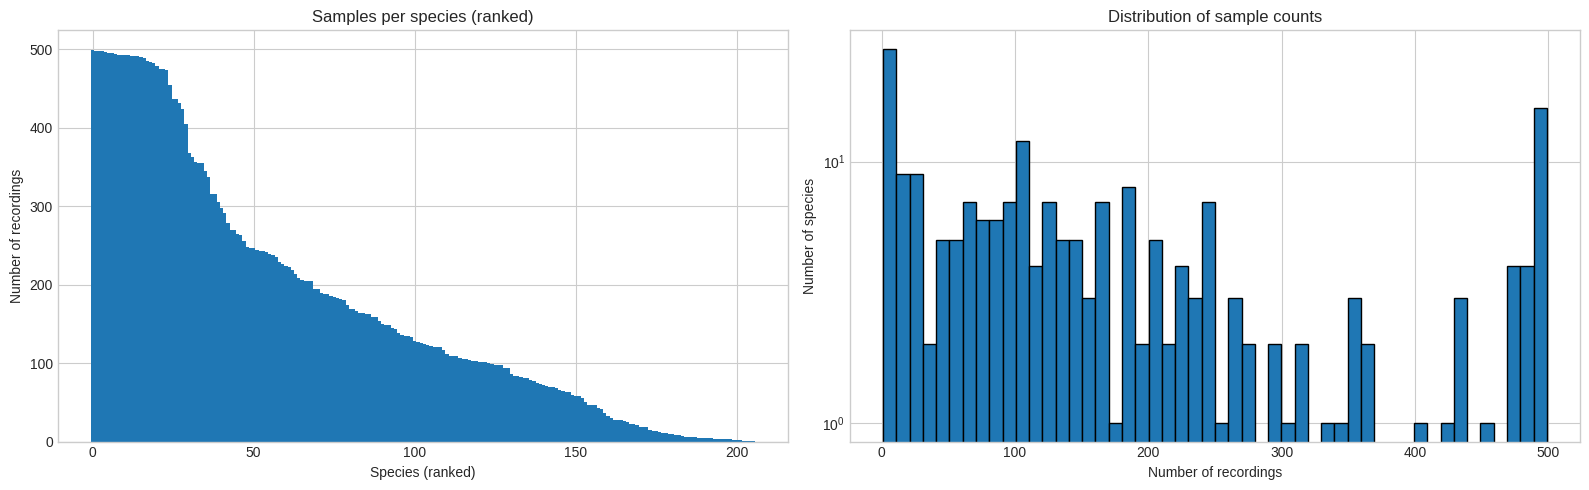

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full ranked bar chart
axes[0].bar(range(len(species_counts)), species_counts.values, width=1.0)
axes[0].set_xlabel('Species (ranked)')
axes[0].set_ylabel('Number of recordings')
axes[0].set_title('Samples per species (ranked)')

# Log-scale histogram
axes[1].hist(species_counts.values, bins=50, edgecolor='black')
axes[1].set_xlabel('Number of recordings')
axes[1].set_ylabel('Number of species')
axes[1].set_title('Distribution of sample counts')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

---
## 3 — Recording Duration & Audio Properties

In [8]:
# If duration isn't in metadata, sample files to measure it
if 'duration' not in meta.columns:
    sample_files = meta.sample(min(500, len(meta)), random_state=42)
    durations, srs, n_channels = [], [], []
    for _, row in sample_files.iterrows():
        fpath = TRAIN_AUDIO / row['filename']
        if fpath.exists():
            info = sf.info(str(fpath))
            durations.append(info.duration)
            srs.append(info.samplerate)
            n_channels.append(info.channels)
    print(f'Sampled {len(durations)} files')
    print(f'Duration  — min: {min(durations):.1f}s, max: {max(durations):.1f}s, median: {np.median(durations):.1f}s')
    print(f'Sample rates: {sorted(set(srs))}')
    print(f'Channels:     {sorted(set(n_channels))}')
else:
    print(meta['duration'].describe())

Sampled 479 files
Duration  — min: 0.0s, max: 859.9s, median: 19.8s
Sample rates: [32000]
Channels:     [1]


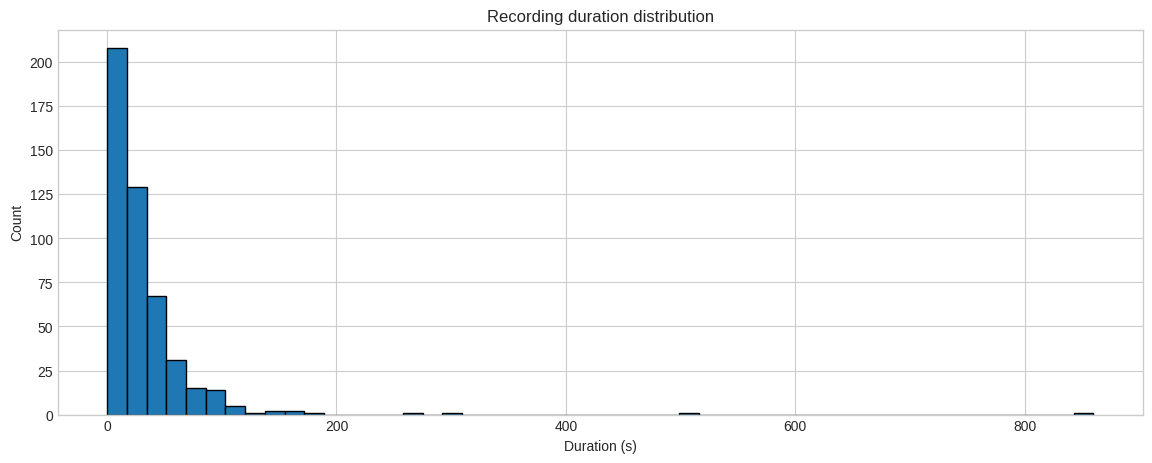

In [9]:
# Duration histogram
if 'duration' not in meta.columns:
    plt.hist(durations, bins=50, edgecolor='black')
else:
    plt.hist(meta['duration'], bins=50, edgecolor='black')
plt.xlabel('Duration (s)')
plt.ylabel('Count')
plt.title('Recording duration distribution')
plt.show()

---
## 4 — Geographic & Temporal Patterns

Recordings with coordinates: 35549/35549


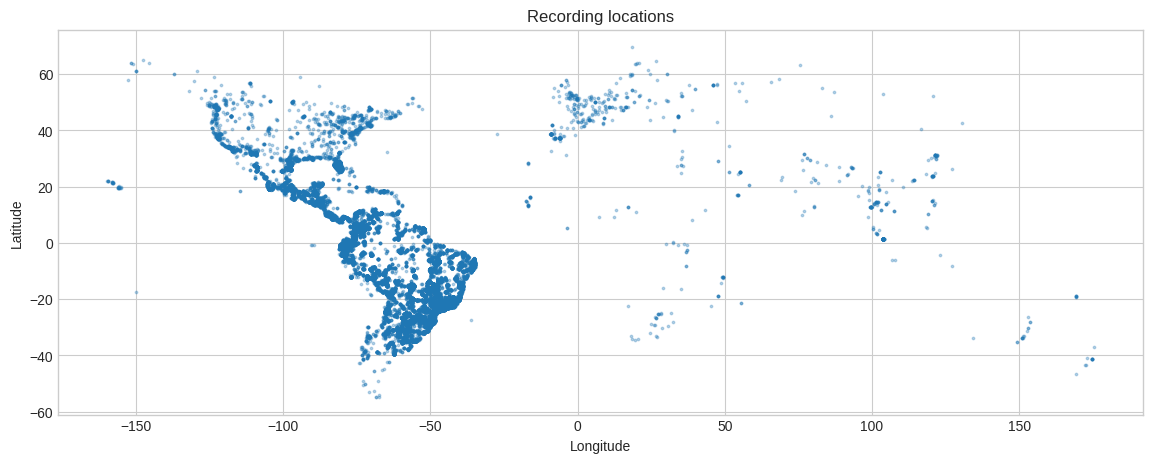

In [10]:
# Geographic spread (if lat/lon available)
lat_col = [c for c in meta.columns if 'lat' in c.lower()]
lon_col = [c for c in meta.columns if 'lon' in c.lower() or 'lng' in c.lower()]

if lat_col and lon_col:
    lat, lon = lat_col[0], lon_col[0]
    valid_geo = meta.dropna(subset=[lat, lon])
    print(f'Recordings with coordinates: {len(valid_geo)}/{len(meta)}')
    plt.scatter(valid_geo[lon], valid_geo[lat], alpha=0.3, s=3)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Recording locations')
    plt.show()
else:
    print('No lat/lon columns found')

In [11]:
# Temporal patterns (if date/time columns exist)
date_col = [c for c in meta.columns if 'date' in c.lower()]
if date_col:
    meta['_date'] = pd.to_datetime(meta[date_col[0]], errors='coerce')
    meta['_month'] = meta['_date'].dt.month
    meta['_month'].value_counts().sort_index().plot(kind='bar')
    plt.title('Recordings by month')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.show()
else:
    print('No date column found')

No date column found


---
## 5 — Label Quality & Secondary Labels

rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64


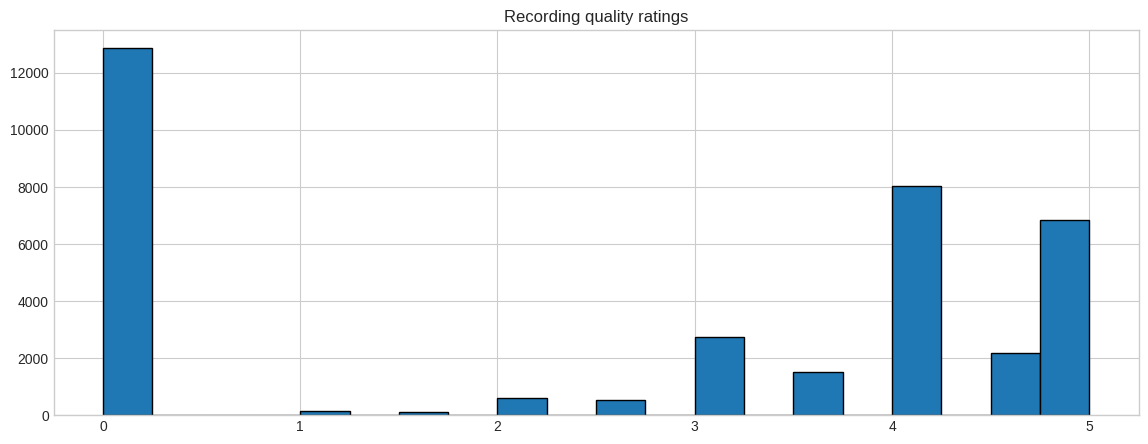

Recordings with secondary labels: 4372 (12.3%)


In [12]:
# Rating distribution (if present)
if 'rating' in meta.columns:
    print(meta['rating'].value_counts().sort_index())
    meta['rating'].hist(bins=20, edgecolor='black')
    plt.title('Recording quality ratings')
    plt.show()

# Secondary labels
if 'secondary_labels' in meta.columns:
    has_secondary = meta['secondary_labels'].notna() & (meta['secondary_labels'] != '[]')
    print(f'Recordings with secondary labels: {has_secondary.sum()} ({has_secondary.mean()*100:.1f}%)')

---
## 5b — File Existence Check

Verify all metadata entries have a corresponding audio file on disk.

In [13]:
missing = []
for fname in meta['filename']:
    if not (TRAIN_AUDIO / fname).exists():
        missing.append(fname)

print(f'Missing files: {len(missing)} / {len(meta)}')
if missing:
    print('Examples:', missing[:10])


Missing files: 1093 / 35549
Examples: ['chobla1/iNat405542.ogg', 'chobla1/iNat343644.ogg', 'chobla1/iNat527889.ogg', 'chobla1/iNat505982.ogg', 'chobla1/iNat831270.ogg', 'chobla1/iNat808308.ogg', 'chobla1/XC992387.ogg', 'chobla1/iNat979810.ogg', 'chobla1/XC930151.ogg', 'chobla1/iNat1193134.ogg']


---
## 6 — Spectrogram Spot-Check

Visual inspection of a few samples from common, mid-frequency, and rare species.

In [14]:
def plot_melspec(filepath, title='', sr=SAMPLE_RATE, offset=0, duration=5):
    """Load a clip and display its mel spectrogram + playback widget."""
    y, sr_orig = librosa.load(filepath, sr=sr, offset=offset, duration=duration)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(figsize=(12, 3))
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax, fmax=16000)
    ax.set_title(title)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    display(Audio(y, rate=sr))

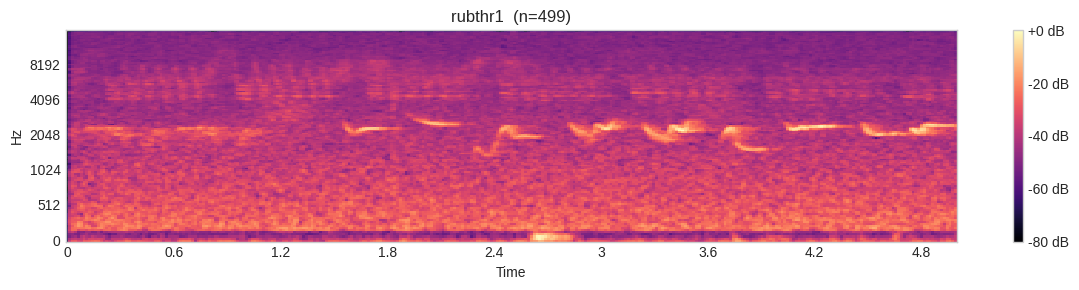

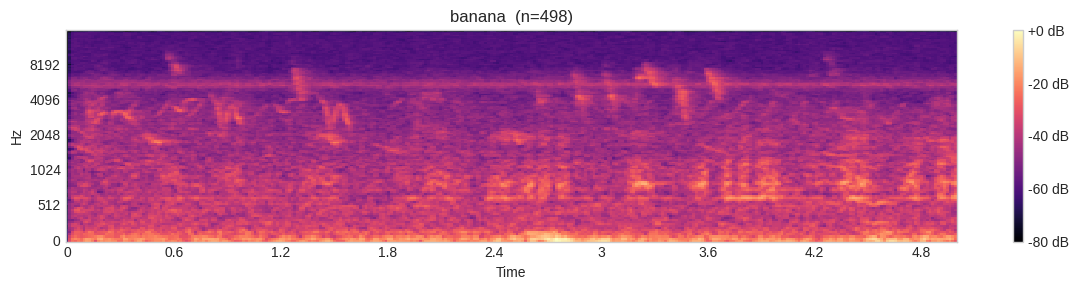

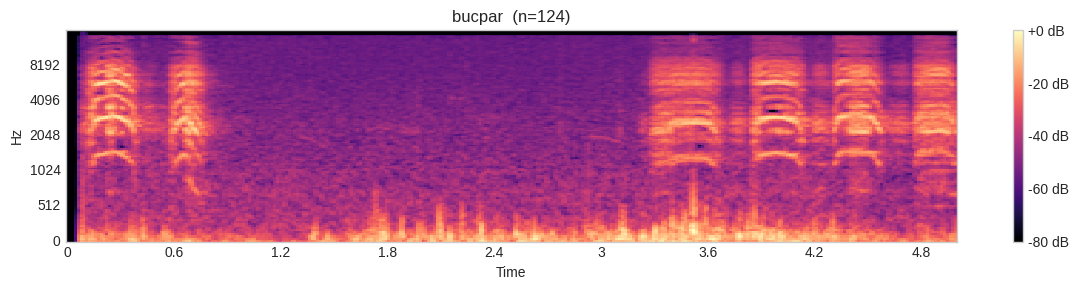

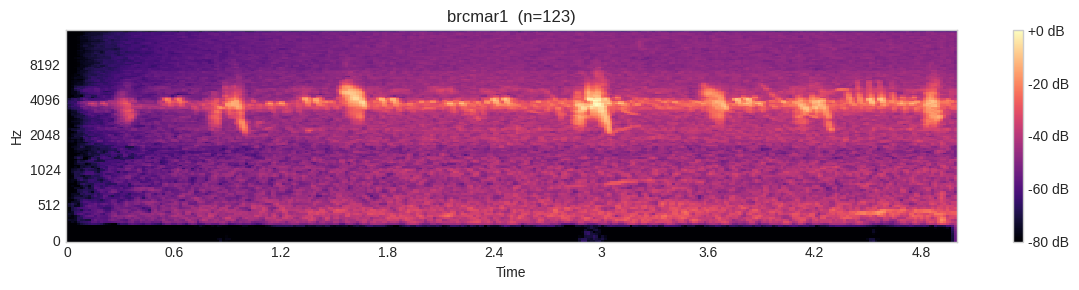

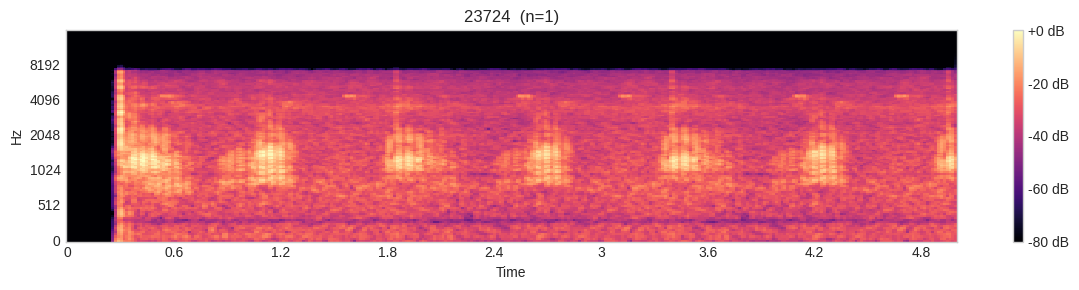

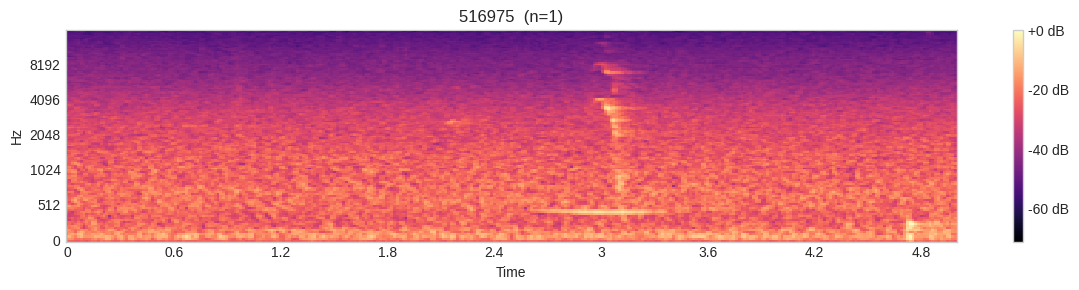

In [15]:
# Pick 2 common, 2 mid, 2 rare species and plot one sample each
rare = species_counts.tail(2).index.tolist()
mid = species_counts.iloc[len(species_counts)//2 : len(species_counts)//2 + 2].index.tolist()
common = species_counts.head(2).index.tolist()

for label in common + mid + rare:
    row = meta[meta['primary_label'] == label].iloc[0]
    fpath = TRAIN_AUDIO / row['filename']
    n = species_counts[label]
    plot_melspec(fpath, title=f'{label}  (n={n})')

---
## 6b — Train Soundscapes Exploration

Expert-annotated soundscapes are high-value anchors for validation and pseudo-label calibration.

In [16]:
TRAIN_SOUNDSCAPES = DATA_DIR / 'train_soundscapes'
SOUNDSCAPE_META = DATA_DIR / 'train_soundscape_labels.csv'  # adjust name if different

if TRAIN_SOUNDSCAPES.exists():
    ss_files = list(TRAIN_SOUNDSCAPES.glob('*'))
    print(f'Train soundscape files: {len(ss_files)}')
    # Show total duration
    ss_durations = []
    for f in ss_files[:50]:  # sample for speed
        try:
            info = sf.info(str(f))
            ss_durations.append(info.duration)
        except:
            pass
    if ss_durations:
        print(f'Duration (sampled {len(ss_durations)}): min={min(ss_durations):.0f}s, max={max(ss_durations):.0f}s, median={np.median(ss_durations):.0f}s')
else:
    print('No train_soundscapes directory found.')

if SOUNDSCAPE_META.exists():
    ss_labels = pd.read_csv(SOUNDSCAPE_META)
    print(f'\nSoundscape labels shape: {ss_labels.shape}')
    print(f'Columns: {list(ss_labels.columns)}')
    print(ss_labels.head())

    # Species overlap with training clips
    if 'primary_label' in ss_labels.columns:
        ss_species = set(ss_labels['primary_label'].unique())
    elif 'species_id' in ss_labels.columns:
        ss_species = set(ss_labels['species_id'].unique())
    else:
        label_cols = [c for c in ss_labels.columns if c not in ['row_id', 'soundscape_id', 'seconds', 'end_time', 'start_time', 'filename', 'audio_id']]
        ss_species = set(label_cols)  # columns-as-species format

    train_species = set(meta['primary_label'].unique())
    print(f'\nSoundscape species: {len(ss_species)}')
    print(f'Training species:   {len(train_species)}')
    print(f'Overlap:            {len(ss_species & train_species)}')
    only_ss = ss_species - train_species
    only_train = train_species - ss_species
    if only_ss:
        print(f'Only in soundscapes ({len(only_ss)}): {list(only_ss)[:10]}')
    if only_train:
        print(f'Only in training ({len(only_train)}): first 10: {list(only_train)[:10]}')
elif not TRAIN_SOUNDSCAPES.exists():
    pass  # already printed
else:
    print('No soundscape label CSV found — check for alternative filenames.')


Train soundscape files: 10658
Duration (sampled 50): min=60s, max=60s, median=60s
No soundscape label CSV found — check for alternative filenames.


---
## 7 — Inference Budget

CPU-only, 90-minute wall-clock limit. Back into the per-window time budget.

In [17]:
# TODO: update these from the competition page / test data structure
N_SOUNDSCAPES = None       # number of test soundscape files
SOUNDSCAPE_DURATION_S = None  # duration of each soundscape
WINDOW_S = 5               # prediction window
TIME_LIMIT_S = 90 * 60     # 90 minutes

if N_SOUNDSCAPES and SOUNDSCAPE_DURATION_S:
    total_windows = N_SOUNDSCAPES * (SOUNDSCAPE_DURATION_S // WINDOW_S)
    budget_per_window = TIME_LIMIT_S / total_windows
    print(f'Total windows:       {total_windows}')
    print(f'Budget per window:   {budget_per_window:.3f}s')
    print(f'Budget per window (ms): {budget_per_window*1000:.1f}ms')
else:
    print('Fill in N_SOUNDSCAPES and SOUNDSCAPE_DURATION_S from the competition page.')

Fill in N_SOUNDSCAPES and SOUNDSCAPE_DURATION_S from the competition page.


---
## 8 — Taxonomy (if provided)

In [18]:
if TAXONOMY.exists():
    tax = pd.read_csv(TAXONOMY)
    print(tax.shape)
    tax.head(10)
else:
    print('No taxonomy file found — check competition data page.')

(234, 5)


---
## 9 — Summary & Decisions for Phase 2

### Key Findings
- **Dataset size:** _fill in_ recordings across _fill in_ species
- **Class imbalance:** _fill in_ species have ≤10 samples — critical for macro-AUC
- **Taxonomic groups:** Not just birds — includes _fill in_ (Insecta, Amphibia, etc.)
- **Collection sources:** _fill in_ — note quality/distribution differences
- **Audio properties:** Typical duration _fill in_s, sample rate _fill in_ Hz
- **Missing files:** _fill in_
- **Soundscape overlap:** _fill in_

### Open Questions for Phase 2 (Validation Design)
1. How should folds be stratified given extreme class imbalance? (stratified by species? by collection source?)
2. Which collection source is closer to test distribution (Pantanal soundscapes)?
3. Should train soundscapes be held out entirely for validation, or mixed in?
4. Are low-rating recordings (rating ≤2) worth keeping, or do they add noise?
5. How to handle non-bird species — same pipeline or separate models?

### Risk List
1. Extreme class imbalance + macro-AUC = rare species dominate the score
2. Domain shift: Xeno-canto focal recordings → passive soundscape monitoring
3. CPU inference budget — model must be small and fast
4. Multi-taxon (not just birds) — vocalization characteristics differ across classes
5. Secondary labels may introduce label noise if not handled carefully